# MNIST 手写数字识别：训练与验证

用纯 **NumPy** 从零实现一个两层全连接神经网络，在 MNIST 上训练并验证。

- **网络结构**：`784 → 50(sigmoid) → 10(softmax)`
- **损失函数**：交叉熵
- **优化方法**：mini-batch 随机梯度下降（SGD），梯度由**反向传播**解析求得
- **数据**：MNIST，60000 训练 + 10000 测试，28×28 = 784 灰度图

> 仅依赖 `numpy` 和 `matplotlib`，不使用任何深度学习框架。

## 流程

1. 下载并加载 MNIST
2. 定义两层神经网络（前向 + 反向传播）
3. mini-batch SGD 训练
4. 可视化 loss 与 accuracy
5. 在测试集上验证 + 预测示例

In [ ]:
import os
import gzip
import struct
import urllib.request

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def softmax(x):
    # 减去每行最大值，防止指数溢出
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)


# 损失函数，交叉熵误差
# one-hot 的意思是标签是一个向量，只有正确类别的位置是 1，其他位置都是 0
def cross_entropy_error(y, t):
    # y: 预测概率 (batch, 10)，t: one-hot 标签 (batch, 10)
    batch = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch

## 1. 加载 MNIST

从公开镜像下载 4 个 IDX 格式的 `.gz` 文件（首次运行需联网，之后缓存到本地 `./mnist/`），用 NumPy 解析为数组。

- 图像归一化到 `[0, 1]`，展平成 784 维向量
- 标签转成 one-hot 编码（10 维）

In [2]:
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

# 多个镜像，依次尝试
MIRRORS = [
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
]


def _download(filename, save_dir="./mnist"):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, filename)
    if os.path.exists(path):
        return path
    last_err = None
    for base in MIRRORS:
        try:
            print(f"下载 {filename} ...")
            urllib.request.urlretrieve(base + filename, path)
            return path
        except Exception as e:  # 换下一个镜像
            last_err = e
    raise RuntimeError(f"下载 {filename} 失败: {last_err}")


def _load_images(path):
    with gzip.open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, rows * cols)


def _load_labels(path):
    with gzip.open(path, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data


def to_one_hot(labels, num_classes=10):
    out = np.zeros((labels.size, num_classes))
    out[np.arange(labels.size), labels] = 1
    return out


def load_mnist(normalize=True, one_hot=True):
    x_train = _load_images(_download(FILES["train_images"]))
    t_train = _load_labels(_download(FILES["train_labels"]))
    x_test = _load_images(_download(FILES["test_images"]))
    t_test = _load_labels(_download(FILES["test_labels"]))

    if normalize:
        x_train = x_train.astype(np.float32) / 255.0
        x_test = x_test.astype(np.float32) / 255.0
    if one_hot:
        t_train = to_one_hot(t_train)
        t_test = to_one_hot(t_test)
    return (x_train, t_train), (x_test, t_test)

x_train: (60000, 784) t_train: (60000, 10)
x_test : (10000, 784) t_test : (10000, 10)


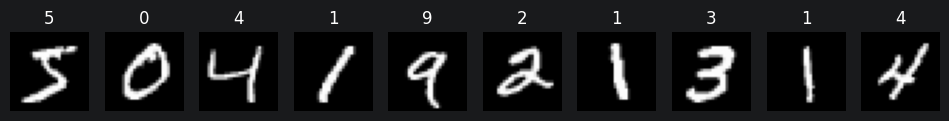

In [3]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot=True)

print("x_train:", x_train.shape, "t_train:", t_train.shape)
print("x_test :", x_test.shape, "t_test :", t_test.shape)

# 预览前 10 张图像
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(int(np.argmax(t_train[i])))
    ax.axis("off")
plt.show()

## 2. 定义两层神经网络

结构：`输入(784) → Affine → Sigmoid → Affine → Softmax → 输出(10)`

- `predict`：前向传播，输出各类别概率
- `loss`：交叉熵损失
- `accuracy`：分类准确率
- `gradient`：**反向传播**解析求梯度（比数值微分快几个数量级）

反向传播关键公式：
- Softmax + 交叉熵的输出层梯度：$\dfrac{\partial L}{\partial a_2} = \dfrac{y - t}{N}$
- Sigmoid 反向：$\dfrac{\partial L}{\partial a_1} = \dfrac{\partial L}{\partial z_1}\cdot z_1(1 - z_1)$

In [ ]:
class TwoLayerNet:
    # input_size: 输入层神经元数量，28*28=784
    # hidden_size: 隐藏层神经元数量，这里我们设置为 50
    # output_size: 输出层神经元数量，10 个类别
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01, seed=0):
        rng = np.random.default_rng(seed)
        self.params = {
            "W1": weight_init_std * rng.standard_normal((input_size, hidden_size)),
            "b1": np.zeros(hidden_size),
            "W2": weight_init_std * rng.standard_normal((hidden_size, output_size)),
            "b2": np.zeros(output_size),
        }

    def predict(self, x):
        W1, W2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]
        a1 = x @ W1 + b1
        z1 = sigmoid(a1)
        a2 = z1 @ W2 + b2
        return softmax(a2)

    def loss(self, x, t):
        y = self.predict(x)
        return cross_entropy_error(y, t)

    # 评价识别精度，即能在多大程度上正确分类
    def accuracy(self, x, t):
        y = self.predict(x)
        pred = np.argmax(y, axis=1)
        label = np.argmax(t, axis=1)
        return np.mean(pred == label)

    def gradient(self, x, t):
        W1, W2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]
        batch = x.shape[0]

        # 前向
        a1 = x @ W1 + b1
        z1 = sigmoid(a1)
        a2 = z1 @ W2 + b2
        y = softmax(a2)

        # 反向
        grads = {}
        dy = (y - t) / batch              # softmax + 交叉熵
        grads["W2"] = z1.T @ dy
        grads["b2"] = np.sum(dy, axis=0)

        dz1 = dy @ W2.T
        da1 = dz1 * z1 * (1 - z1)         # sigmoid 反向
        grads["W1"] = x.T @ da1
        grads["b1"] = np.sum(da1, axis=0)
        return grads

## 3. 训练（mini-batch SGD）

每次迭代随机抽取一个小批量，计算梯度并更新参数：

$$\theta \leftarrow \theta - \eta \cdot \frac{\partial L}{\partial \theta}$$

每经过 1 个 epoch（遍历完一遍训练集所需的迭代数）记录一次训练/测试准确率。

In [5]:
net = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000        # 迭代次数
batch_size = 100         # 批大小
learning_rate = 0.1      # 学习率

train_size = x_train.shape[0]
iter_per_epoch = max(train_size // batch_size, 1)
rng = np.random.default_rng(1)

train_loss_list = []
train_acc_list = []
test_acc_list = []

for i in range(iters_num):
    # 随机取一个 mini-batch
    batch_idx = rng.choice(train_size, batch_size, replace=False)
    x_batch = x_train[batch_idx]
    t_batch = t_train[batch_idx]

    # 反向传播求梯度并更新参数
    grads = net.gradient(x_batch, t_batch)
    for key in net.params:
        net.params[key] -= learning_rate * grads[key]

    train_loss_list.append(net.loss(x_batch, t_batch))

    # 每个 epoch 评估一次
    if i % iter_per_epoch == 0:
        train_acc = net.accuracy(x_train, t_train)
        test_acc = net.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f"epoch {len(train_acc_list):2d} | "
              f"train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

print("\n训练完成。最终测试集准确率:", round(test_acc_list[-1], 4))

epoch  1 | train acc: 0.1044 | test acc: 0.1028
epoch  2 | train acc: 0.7758 | test acc: 0.7813
epoch  3 | train acc: 0.8753 | test acc: 0.8813
epoch  4 | train acc: 0.8976 | test acc: 0.8999
epoch  5 | train acc: 0.9073 | test acc: 0.9105
epoch  6 | train acc: 0.9140 | test acc: 0.9173
epoch  7 | train acc: 0.9190 | test acc: 0.9216
epoch  8 | train acc: 0.9239 | test acc: 0.9256
epoch  9 | train acc: 0.9288 | test acc: 0.9299
epoch 10 | train acc: 0.9309 | test acc: 0.9327
epoch 11 | train acc: 0.9341 | test acc: 0.9357
epoch 12 | train acc: 0.9377 | test acc: 0.9364
epoch 13 | train acc: 0.9401 | test acc: 0.9395
epoch 14 | train acc: 0.9422 | test acc: 0.9414
epoch 15 | train acc: 0.9442 | test acc: 0.9434
epoch 16 | train acc: 0.9458 | test acc: 0.9443
epoch 17 | train acc: 0.9484 | test acc: 0.9472

训练完成。最终测试集准确率: 0.9472


## 4. 可视化 loss 与 accuracy

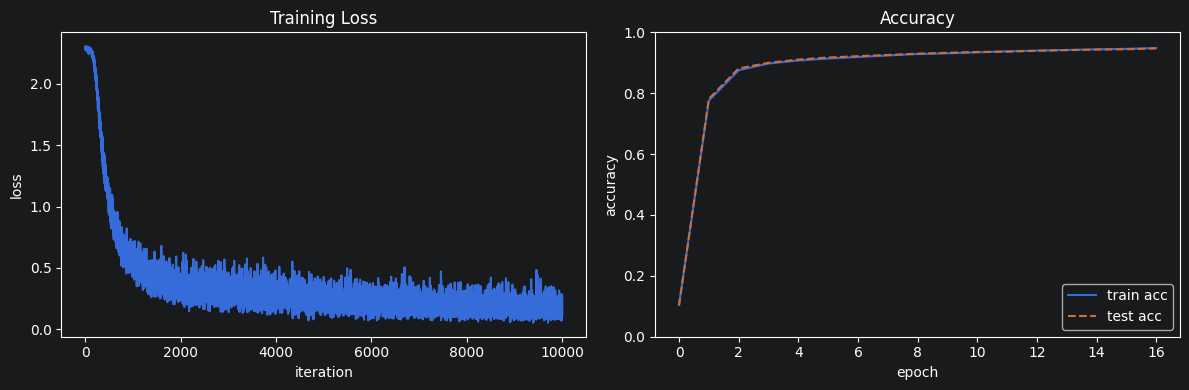

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 训练 loss
ax1.plot(train_loss_list)
ax1.set_title("Training Loss")
ax1.set_xlabel("iteration")
ax1.set_ylabel("loss")

# 训练/测试准确率
epochs = np.arange(len(train_acc_list))
ax2.plot(epochs, train_acc_list, label="train acc")
ax2.plot(epochs, test_acc_list, label="test acc", linestyle="--")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy")
ax2.set_ylim(0, 1.0)
ax2.legend()

plt.tight_layout()
plt.show()

## 5. 在测试集上验证 + 预测示例

输出整体测试准确率，并随机展示若干样本的预测结果（绿色=正确，红色=错误）。

测试集准确率: 0.9477 (94.77%)


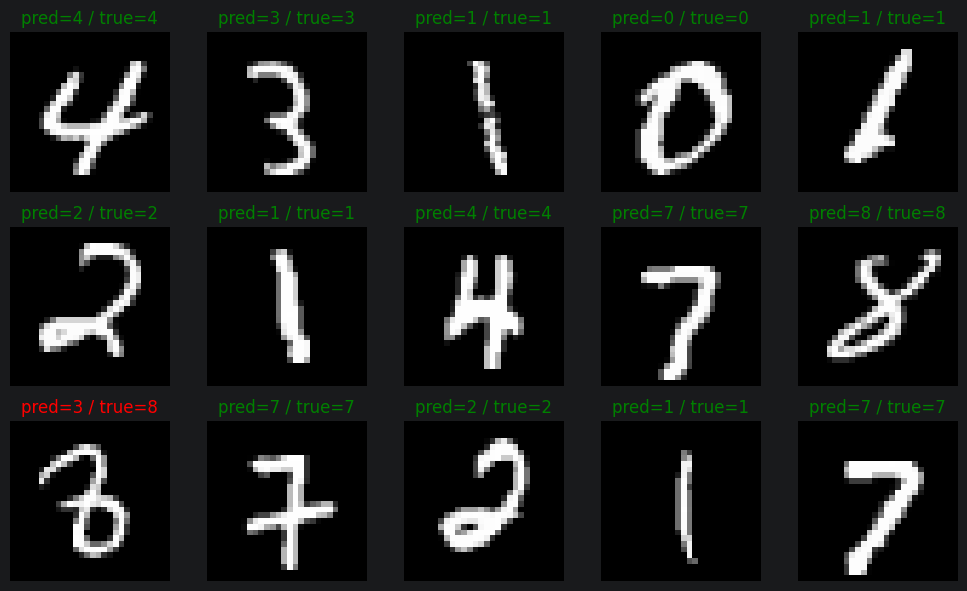

In [7]:
# 整体测试准确率
final_acc = net.accuracy(x_test, t_test)
print(f"测试集准确率: {final_acc:.4f} ({final_acc*100:.2f}%)")

# 随机展示 15 个预测结果
probs = net.predict(x_test)
preds = np.argmax(probs, axis=1)
labels = np.argmax(t_test, axis=1)

rng_show = np.random.default_rng(2)
idxs = rng_show.choice(len(x_test), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for ax, i in zip(axes.ravel(), idxs):
    ax.imshow(x_test[i].reshape(28, 28), cmap="gray")
    correct = preds[i] == labels[i]
    ax.set_title(f"pred={preds[i]} / true={labels[i]}",
                 color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()